# Planetary Gear System Designer for 3D Printing

This notebook provides an interactive tool for designing planetary gear systems optimized for 3D printing with 0.4mm filament constraints. 

## User Inputs:
- **Ring Diameter**: Target outer diameter of the ring gear (mm)
- **Gear Ratio**: Desired gear reduction ratio

## Features:
- Automatic calculation of sun, planet, and ring gear dimensions
- 3D printing optimization with appropriate clearances and tolerances
- STL export for each gear component
- Validation of meshing conditions and mechanical constraints

In [ ]:
# Import Required Libraries
import numpy as np
import cadquery as cq
from jupyter_cadquery import show, set_defaults
import warnings

# Configure jupyter_cadquery display settings
set_defaults(axes=False, axes0=True, grid=(True, True, True),
             default_color='lightgrey', tools=False)

# Import from the proper Python modules in the src directory
import sys
sys.path.append('../src')

from Ring_gear import RingGear, HerringboneRingGear, PlanetaryGearset, HerringbonePlanetaryGearset
from spur_gear import SpurGear
from utilization import *

print("✓ Libraries imported successfully!")
print("✓ Gear modules loaded from ../src/")
print("✓ Ready to design planetary gear systems!")

✓ Libraries imported successfully!
✓ Gear modules loaded from ../src/
✓ Ready to design planetary gear systems!

✓ Gear modules loaded from ../src/
✓ Ready to design planetary gear systems!


## 🔧 User Input Parameters

Configure your planetary gear system by setting the following parameters:

In [89]:
# ========================================
# 🔧 USER INPUT PARAMETERS
# ========================================
# Modify these values to customize your planetary gear system

# Main Design Parameters
RING_OUTER_DIAMETER = 50.0    # mm - Target outer diameter of the ring gear
GEAR_RATIO = 6.0               # Desired gear reduction ratio (output/input)

# 3D Printing Parameters (for 0.4mm filament)
FILAMENT_DIAMETER = 0.4        # mm - Nozzle/filament diameter
MIN_WALL_THICKNESS = 0.8       # mm - Minimum wall thickness (2x filament diameter)
PRINTING_CLEARANCE = 0.2       # mm - Clearance between meshing parts for 3D printing
LAYER_HEIGHT = 0.2             # mm - Typical layer height for 0.4mm nozzle

# Advanced Parameters (usually don't need to change)
PRESSURE_ANGLE = 20.0          # degrees - Standard gear pressure angle
GEAR_WIDTH = 5.0              # mm - Width/thickness of all gears
SUN_BORE_DIAMETER = 6.0        # mm - Central bore for sun gear shaft
RIM_WIDTH = 2.5                # mm - Ring gear rim thickness

print("🔧 User Parameters Set:")
print(f"   Ring Outer Diameter: {RING_OUTER_DIAMETER:.1f} mm")
print(f"   Gear Ratio: {GEAR_RATIO:.1f}:1")
print(f"   3D Printing Clearance: {PRINTING_CLEARANCE:.2f} mm")
print(f"   Minimum Wall Thickness: {MIN_WALL_THICKNESS:.2f} mm")
print(f"   Filament Diameter: {FILAMENT_DIAMETER:.2f} mm")
print("\n✓ Ready to calculate gear dimensions!")

🔧 User Parameters Set:
   Ring Outer Diameter: 50.0 mm
   Gear Ratio: 6.0:1
   3D Printing Clearance: 0.20 mm
   Minimum Wall Thickness: 0.80 mm

   Ring Outer Diameter: 50.0 mm
   Gear Ratio: 6.0:1
   3D Printing Clearance: 0.20 mm
   Minimum Wall Thickness: 0.80 mm
   Filament Diameter: 0.40 mm

✓ Ready to calculate gear dimensions!
   Filament Diameter: 0.40 mm

✓ Ready to calculate gear dimensions!


## 📐 Calculate Planetary Gear Dimensions

Based on the user inputs, calculate the optimal tooth counts and dimensions for sun, planet, and ring gears.

In [90]:
def calculate_planetary_teeth(gear_ratio, max_ring_teeth=100, min_sun_teeth=12):
    """
    Calculate optimal tooth counts for planetary gear system
    
    For planetary gears:
    - Gear ratio = 1 + (ring_teeth / sun_teeth)
    - Ring_teeth = sun_teeth + 2 * planet_teeth
    - (sun_teeth + ring_teeth) must be divisible by number_of_planets
    
    Args:
        gear_ratio: Desired gear ratio
        max_ring_teeth: Maximum allowed ring teeth (for practical size limits)
        min_sun_teeth: Minimum sun teeth (for strength)
    
    Returns:
        dict: Optimal tooth counts
    """
    
    best_config = None
    best_score = float('inf')
    
    print(f"🔍 Searching for optimal tooth counts for gear ratio {gear_ratio:.1f}:1")
    print(f"   Constraints: Sun teeth >= {min_sun_teeth}, Ring teeth <= {max_ring_teeth}")
    
    for sun_teeth in range(min_sun_teeth, 50):  # Reasonable range for sun teeth
        # Calculate required ring teeth for the desired gear ratio
        ring_teeth = round(sun_teeth * (gear_ratio - 1))
        
        if ring_teeth > max_ring_teeth:
            continue
            
        # Calculate planet teeth: Ring = Sun + 2*Planet
        if (ring_teeth - sun_teeth) % 2 != 0:
            continue  # Planet teeth must be integer
            
        planet_teeth = (ring_teeth - sun_teeth) // 2
        
        if planet_teeth <= 0:
            continue
            
        # Check planetary gear constraints for 4 planets (fixed)
        n_planets = 4
        constraint1 = (sun_teeth + ring_teeth) % n_planets == 0
        constraint2 = (sun_teeth + planet_teeth) % n_planets == 0
        
        if constraint1 and constraint2:
            actual_ratio = 1 + (ring_teeth / sun_teeth)
            ratio_error = abs(actual_ratio - gear_ratio)
            
            # Score based on ratio accuracy and practical considerations
            score = ratio_error * 100 + abs(sun_teeth - 20) * 0.1  # Prefer ~20 sun teeth
            
            if score < best_score:
                best_score = score
                best_config = {
                    'sun_teeth': sun_teeth,
                    'planet_teeth': planet_teeth,
                    'ring_teeth': ring_teeth,
                    'n_planets': n_planets,
                    'actual_ratio': actual_ratio,
                    'ratio_error': ratio_error
                }
    
    return best_config

def calculate_gear_dimensions(config, ring_outer_diameter):
    """
    Calculate physical dimensions based on tooth counts and target ring diameter
    """
    
    # Calculate module based on ring outer diameter
    # Ring outer radius = (ring_teeth * module / 2) + rim_width
    # Solve for module: module = 2 * (ring_outer_diameter/2 - rim_width) / ring_teeth
    ring_outer_radius = ring_outer_diameter / 2
    available_radius_for_teeth = ring_outer_radius - RIM_WIDTH
    module = 2 * available_radius_for_teeth / config['ring_teeth']
    
    # Calculate radii
    sun_radius = config['sun_teeth'] * module / 2
    planet_radius = config['planet_teeth'] * module / 2
    ring_inner_radius = config['ring_teeth'] * module / 2
    
    # Calculate orbit radius (center of sun to center of planet)
    orbit_radius = sun_radius + planet_radius
    
    # Verify ring gear can accommodate planets
    required_ring_inner_radius = orbit_radius + planet_radius
    
    if ring_inner_radius < required_ring_inner_radius:
        warnings.warn(f"Ring gear too small! Required inner radius: {required_ring_inner_radius:.2f}, "
                     f"Available: {ring_inner_radius:.2f}")
    
    return {
        'module': module,
        'sun_radius': sun_radius,
        'planet_radius': planet_radius,
        'ring_inner_radius': ring_inner_radius,
        'ring_outer_radius': ring_outer_radius,
        'orbit_radius': orbit_radius
    }

# Calculate optimal tooth configuration
print("=" * 60)
print("📐 PLANETARY GEAR DIMENSION CALCULATION")
print("=" * 60)

tooth_config = calculate_planetary_teeth(GEAR_RATIO)

if tooth_config is None:
    print("❌ Could not find valid tooth configuration for the specified gear ratio!")
    print("Try adjusting the gear ratio or constraints.")
else:
    print(f"\n✅ Optimal Configuration Found:")
    print(f"   Sun gear: {tooth_config['sun_teeth']} teeth")
    print(f"   Planet gear: {tooth_config['planet_teeth']} teeth")
    print(f"   Ring gear: {tooth_config['ring_teeth']} teeth")
    print(f"   Number of planets: {tooth_config['n_planets']}")
    print(f"   Actual gear ratio: {tooth_config['actual_ratio']:.3f}:1")
    print(f"   Ratio error: {tooth_config['ratio_error']:.3f}")
    
    # Calculate physical dimensions
    dimensions = calculate_gear_dimensions(tooth_config, RING_OUTER_DIAMETER)
    
    print(f"\n📏 Physical Dimensions:")
    print(f"   Module: {dimensions['module']:.3f} mm")
    print(f"   Sun radius: {dimensions['sun_radius']:.2f} mm")
    print(f"   Planet radius: {dimensions['planet_radius']:.2f} mm") 
    print(f"   Ring inner radius: {dimensions['ring_inner_radius']:.2f} mm")
    print(f"   Ring outer radius: {dimensions['ring_outer_radius']:.2f} mm")
    print(f"   Orbit radius: {dimensions['orbit_radius']:.2f} mm")
    
    # Verify 3D printing constraints
    print(f"\n🖨️  3D Printing Validation:")
    tooth_thickness = dimensions['module'] * np.pi / 4  # Approximate tooth thickness
    print(f"   Approximate tooth thickness: {tooth_thickness:.2f} mm")
    
    if tooth_thickness < MIN_WALL_THICKNESS:
        print(f"   ⚠️  Warning: Tooth thickness ({tooth_thickness:.2f} mm) < minimum wall thickness ({MIN_WALL_THICKNESS:.2f} mm)")
        print(f"      Consider increasing ring diameter or reducing gear ratio")
    else:
        print(f"   ✅ Tooth thickness adequate for 3D printing")
        
    print(f"   Planned clearance: {PRINTING_CLEARANCE:.2f} mm")
    print(f"   Layer height: {LAYER_HEIGHT:.2f} mm")

📐 PLANETARY GEAR DIMENSION CALCULATION
🔍 Searching for optimal tooth counts for gear ratio 6.0:1
   Constraints: Sun teeth >= 12, Ring teeth <= 100

✅ Optimal Configuration Found:
   Sun gear: 20 teeth
   Planet gear: 40 teeth

📐 PLANETARY GEAR DIMENSION CALCULATION
🔍 Searching for optimal tooth counts for gear ratio 6.0:1
   Constraints: Sun teeth >= 12, Ring teeth <= 100

✅ Optimal Configuration Found:
   Sun gear: 20 teeth
   Planet gear: 40 teeth
   Ring gear: 100 teeth
   Number of planets: 4
   Actual gear ratio: 6.000:1
   Ratio error: 0.000

📏 Physical Dimensions:
   Module: 0.450 mm
   Sun radius: 4.50 mm
   Planet radius: 9.00 mm
   Ring inner radius: 22.50 mm
   Ring gear: 100 teeth
   Number of planets: 4
   Actual gear ratio: 6.000:1
   Ratio error: 0.000

📏 Physical Dimensions:
   Module: 0.450 mm
   Sun radius: 4.50 mm
   Planet radius: 9.00 mm
   Ring inner radius: 22.50 mm
   Ring outer radius: 25.00 mm
   Orbit radius: 13.50 mm

🖨️  3D Printing Validation:
   Approxim

## ⚙️ Generate Gear Components

Create the individual gear components with 3D printing optimizations.

In [91]:
def create_3d_printable_gears(tooth_config, dimensions, clearance=0.2):
    """
    Create 3D printable gear components with appropriate clearances
    
    Args:
        tooth_config: Dictionary with tooth counts
        dimensions: Dictionary with calculated dimensions
        clearance: Printing clearance in mm
    
    Returns:
        Dictionary with built gear objects
    """
    
    module = dimensions['module']
    
    print("🏭 Creating Gear Components...")
    print("=" * 40)
    
    # Sun Gear - Standard spur gear with bore
    print(f"Creating sun gear ({tooth_config['sun_teeth']} teeth)...")
    sun_gear = SpurGear(
        module=module,
        teeth_number=tooth_config['sun_teeth'],
        width=GEAR_WIDTH,
        bore_d=SUN_BORE_DIAMETER,
        pressure_angle=PRESSURE_ANGLE
    )
    sun_built = sun_gear.build()
    print(f"   ✅ Sun gear created - Radius: {sun_gear.r0:.2f} mm")
    
    # Planet Gear - Reduced size for clearance
    print(f"Creating planet gear ({tooth_config['planet_teeth']} teeth)...")
    # Reduce module slightly for clearance
    planet_clearance_factor = 1 - (clearance / (2 * dimensions['planet_radius']))
    planet_module = module * planet_clearance_factor
    
    planet_gear = SpurGear(
        module=planet_module,
        teeth_number=tooth_config['planet_teeth'],
        width=GEAR_WIDTH,
        pressure_angle=PRESSURE_ANGLE
    )
    planet_built = planet_gear.build()
    print(f"   ✅ Planet gear created - Original radius: {dimensions['planet_radius']:.2f} mm, "
          f"Reduced radius: {planet_gear.r0:.2f} mm")
    print(f"   📏 Clearance applied: {clearance:.2f} mm")
    
    # Ring Gear - Standard internal gear
    print(f"Creating ring gear ({tooth_config['ring_teeth']} teeth)...")
    ring_gear = RingGear(
        module=module,
        teeth_number=tooth_config['ring_teeth'],
        width=GEAR_WIDTH,
        rim_width=RIM_WIDTH,
        pressure_angle=PRESSURE_ANGLE
    )
    ring_built = ring_gear.build()
    print(f"   ✅ Ring gear created - Inner radius: {ring_gear.r0:.2f} mm, "
          f"Outer radius: {ring_gear.r0 + ring_gear.rim_width:.2f} mm")
    
    return {
        'sun': {'gear': sun_gear, 'built': sun_built},
        'planet': {'gear': planet_gear, 'built': planet_built},
        'ring': {'gear': ring_gear, 'built': ring_built}
    }

def create_planetary_assembly(gears, tooth_config, dimensions):
    """
    Assemble the planetary gear system with proper positioning and rotation
    """
    
    print(f"\n🔧 Assembling Planetary Gear System...")
    print("=" * 40)
    
    # Create assembly
    assembly = cq.Assembly(name='planetary_gearset_3d_printable')
    
    # Add sun gear at center
    assembly.add(gears['sun']['built'], name='sun', color=cq.Color('gold'))
    print("   ✅ Sun gear positioned at center")
    
    # Calculate planet positions
    n_planets = tooth_config['n_planets']
    orbit_radius = dimensions['orbit_radius']
    planet_spacing_angle = 2 * np.pi / n_planets
    
    print(f"   🌍 Positioning {n_planets} planet gears...")
    
    for i in range(n_planets):
        # Position angle for this planet
        planet_position_angle = i * planet_spacing_angle
        
        # Calculate planet position
        planet_x = np.cos(planet_position_angle) * orbit_radius
        planet_y = np.sin(planet_position_angle) * orbit_radius
        
        # Calculate rotation for proper meshing
        planet_rotation = planet_position_angle * (tooth_config['sun_teeth'] / tooth_config['planet_teeth'])
        mesh_offset = np.pi / tooth_config['planet_teeth']  # Half tooth pitch for valley-to-tooth meshing
        total_rotation = planet_rotation + mesh_offset
        
        # Create location
        loc = cq.Location(
            cq.Vector(planet_x, planet_y, 0.0),
            cq.Vector(0.0, 0.0, 1.0),
            np.degrees(total_rotation)
        )
        
        assembly.add(gears['planet']['built'], name=f'planet_{i:02}', 
                    loc=loc, color=cq.Color('lightsteelblue'))
        
        print(f"      Planet {i+1}: position=({planet_x:.1f}, {planet_y:.1f}), "
              f"rotation={np.degrees(total_rotation):.1f}°")
    
    # Add ring gear with alignment adjustment
    ring_tooth_pitch = 2 * np.pi / tooth_config['ring_teeth']
    ring_alignment_factor = 0.5  # Fine-tune if needed
    ring_alignment_rotation = ring_alignment_factor * ring_tooth_pitch
    
    ring_loc = cq.Location(
        cq.Vector(0.0, 0.0, 0.0),
        cq.Vector(0.0, 0.0, 1.0),
        np.degrees(ring_alignment_rotation)
    )
    
    assembly.add(gears['ring']['built'], name='ring', loc=ring_loc, color=cq.Color('goldenrod'))
    print(f"   ✅ Ring gear positioned with {np.degrees(ring_alignment_rotation):.1f}° alignment rotation")
    
    return assembly

# Only proceed if we have a valid tooth configuration
if tooth_config is not None:
    # Create the gear components
    gear_components = create_3d_printable_gears(tooth_config, dimensions, PRINTING_CLEARANCE)
    
    # Create the assembled system
    planetary_assembly = create_planetary_assembly(gear_components, tooth_config, dimensions)
    
    # Convert to compound for volume calculation and export
    planetary_compound = planetary_assembly.toCompound()
    
    print(f"\n📊 Assembly Statistics:")
    print(f"   Total volume: {planetary_compound.Volume():.2f} mm³")
    print(f"   Bounding box: {planetary_compound.BoundingBox()}")
    
    # Display the assembly (if jupyter_cadquery is available)
    try:
        show(planetary_assembly)
        print("   ✅ 3D preview displayed above")
    except:
        print("   ℹ️  3D preview not available (jupyter_cadquery not configured)")
    
    print("\n✅ Planetary gear system successfully generated!")
else:
    print("❌ Cannot create gears - no valid tooth configuration found.")

🏭 Creating Gear Components...
Creating sun gear (20 teeth)...

Creating sun gear (20 teeth)...
   ✅ Sun gear created - Radius: 4.50 mm
Creating planet gear (40 teeth)...
   ✅ Sun gear created - Radius: 4.50 mm
Creating planet gear (40 teeth)...
   ✅ Planet gear created - Original radius: 9.00 mm, Reduced radius: 8.90 mm
   📏 Clearance applied: 0.20 mm
Creating ring gear (100 teeth)...
   ✅ Planet gear created - Original radius: 9.00 mm, Reduced radius: 8.90 mm
   📏 Clearance applied: 0.20 mm
Creating ring gear (100 teeth)...
   ✅ Ring gear created - Inner radius: 22.50 mm, Outer radius: 25.00 mm

🔧 Assembling Planetary Gear System...
   ✅ Sun gear positioned at center
   🌍 Positioning 4 planet gears...
      Planet 1: position=(13.5, 0.0), rotation=4.5°
      Planet 2: position=(0.0, 13.5), rotation=49.5°
      Planet 3: position=(-13.5, 0.0), rotation=94.5°
      Planet 4: position=(-0.0, -13.5), rotation=139.5°   ✅ Ring gear created - Inner radius: 22.50 mm, Outer radius: 25.00 mm

🔧

CadViewerWidget(anchor=None, aspect_ratio=0.75, cad_width=800, control='trackball', glass=True, height=600, id…

   ℹ️  3D preview not available (jupyter_cadquery not configured)

✅ Planetary gear system successfully generated!


✅ Planetary gear system successfully generated!


## 📊 2D Visualization

Visualize the planetary gear system layout showing all gear circles in 2D for better understanding of the arrangement.

📊 Creating 2D Gear Layout Visualization...



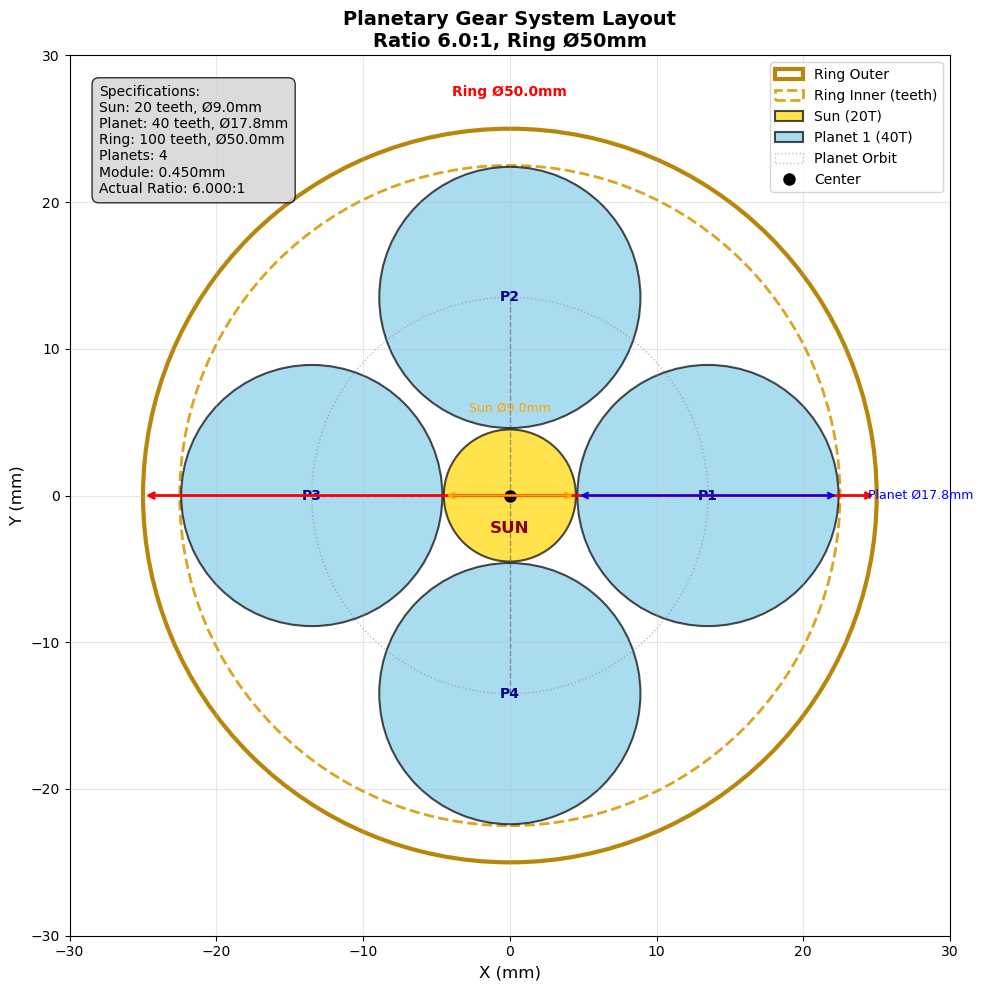

✅ 2D visualization created!
   Shows gear arrangement with 4 planets
   All dimensions in mm, clearances applied to planet gears

   Shows gear arrangement with 4 planets
   All dimensions in mm, clearances applied to planet gears


In [92]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import Circle

def visualize_gear_layout_2d(tooth_config, dimensions, gear_components):
    """
    Create a 2D visualization showing all gear circles and their arrangement
    """
    
    print("📊 Creating 2D Gear Layout Visualization...")
    
    # Create figure and axis
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    
    # Get dimensions
    sun_radius = gear_components['sun']['gear'].r0
    planet_radius = gear_components['planet']['gear'].r0
    ring_inner_radius = gear_components['ring']['gear'].r0
    ring_outer_radius = ring_inner_radius + gear_components['ring']['gear'].rim_width
    orbit_radius = dimensions['orbit_radius']
    n_planets = tooth_config['n_planets']
    
    # Colors for different components
    colors = {
        'sun': '#FFD700',        # Gold
        'planet': '#87CEEB',     # Sky blue
        'ring': '#DAA520',       # Goldenrod
        'ring_outer': '#B8860B'  # Dark goldenrod
    }
    
    # Draw ring gear (outer and inner circles)
    ring_outer_circle = Circle((0, 0), ring_outer_radius, 
                              fill=False, edgecolor=colors['ring_outer'], 
                              linewidth=3, linestyle='-', label='Ring Outer')
    ring_inner_circle = Circle((0, 0), ring_inner_radius, 
                              fill=False, edgecolor=colors['ring'], 
                              linewidth=2, linestyle='--', label='Ring Inner (teeth)')
    ax.add_patch(ring_outer_circle)
    ax.add_patch(ring_inner_circle)
    
    # Draw sun gear
    sun_circle = Circle((0, 0), sun_radius, 
                       fill=True, facecolor=colors['sun'], 
                       edgecolor='black', alpha=0.7, linewidth=1.5, 
                       label=f'Sun ({tooth_config["sun_teeth"]}T)')
    ax.add_patch(sun_circle)
    
    # Draw planet gears
    planet_spacing_angle = 2 * np.pi / n_planets
    
    for i in range(n_planets):
        # Calculate planet position
        angle = i * planet_spacing_angle
        planet_x = np.cos(angle) * orbit_radius
        planet_y = np.sin(angle) * orbit_radius
        
        # Draw planet gear
        planet_circle = Circle((planet_x, planet_y), planet_radius, 
                             fill=True, facecolor=colors['planet'], 
                             edgecolor='black', alpha=0.7, linewidth=1.5,
                             label=f'Planet {i+1} ({tooth_config["planet_teeth"]}T)' if i == 0 else "")
        ax.add_patch(planet_circle)
        
        # Draw line from center to planet center (orbit radius)
        ax.plot([0, planet_x], [0, planet_y], 'k--', alpha=0.3, linewidth=1)
        
        # Add planet number label
        ax.text(planet_x, planet_y, f'P{i+1}', ha='center', va='center', 
                fontweight='bold', fontsize=10, color='darkblue')
    
    # Draw orbit circle (dashed line showing planet centers)
    orbit_circle = Circle((0, 0), orbit_radius, 
                         fill=False, edgecolor='gray', 
                         linewidth=1, linestyle=':', alpha=0.5, 
                         label='Planet Orbit')
    ax.add_patch(orbit_circle)
    
    # Add center point
    ax.plot(0, 0, 'ko', markersize=8, label='Center')
    ax.text(0, -sun_radius/2, 'SUN', ha='center', va='center', 
            fontweight='bold', fontsize=12, color='darkred')
    
    # Add dimensions annotations
    # Ring outer diameter
    ax.annotate('', xy=(-ring_outer_radius, 0), xytext=(ring_outer_radius, 0),
                arrowprops=dict(arrowstyle='<->', color='red', lw=2))
    ax.text(0, ring_outer_radius + 2, f'Ring Ø{ring_outer_radius*2:.1f}mm', 
            ha='center', va='bottom', fontsize=10, color='red', fontweight='bold')
    
    # Sun diameter
    ax.annotate('', xy=(-sun_radius, 0), xytext=(sun_radius, 0),
                arrowprops=dict(arrowstyle='<->', color='orange', lw=1.5))
    ax.text(0, sun_radius + 1, f'Sun Ø{sun_radius*2:.1f}mm', 
            ha='center', va='bottom', fontsize=9, color='orange')
    
    # Planet diameter (on first planet)
    planet_angle = 0
    planet_x = np.cos(planet_angle) * orbit_radius
    planet_y = np.sin(planet_angle) * orbit_radius
    
    ax.annotate('', xy=(planet_x - planet_radius, planet_y), 
                xytext=(planet_x + planet_radius, planet_y),
                arrowprops=dict(arrowstyle='<->', color='blue', lw=1.5))
    ax.text(planet_x + planet_radius + 2, planet_y, 
            f'Planet Ø{planet_radius*2:.1f}mm', 
            ha='left', va='center', fontsize=9, color='blue')
    
    # Set equal aspect ratio and limits
    max_radius = ring_outer_radius + 5
    ax.set_xlim(-max_radius, max_radius)
    ax.set_ylim(-max_radius, max_radius)
    ax.set_aspect('equal')
    
    # Grid and labels
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('X (mm)', fontsize=12)
    ax.set_ylabel('Y (mm)', fontsize=12)
    ax.set_title(f'Planetary Gear System Layout\nRatio {GEAR_RATIO:.1f}:1, Ring Ø{RING_OUTER_DIAMETER:.0f}mm', 
                 fontsize=14, fontweight='bold')
    
    # Legend
    handles, labels = ax.get_legend_handles_labels()
    # Remove duplicate planet labels
    unique_labels = []
    unique_handles = []
    for handle, label in zip(handles, labels):
        if label not in unique_labels:
            unique_labels.append(label)
            unique_handles.append(handle)
    
    ax.legend(unique_handles, unique_labels, loc='upper right', bbox_to_anchor=(1.0, 1.0))
    
    # Add specifications text box
    specs_text = f"""Specifications:
Sun: {tooth_config['sun_teeth']} teeth, Ø{sun_radius*2:.1f}mm
Planet: {tooth_config['planet_teeth']} teeth, Ø{planet_radius*2:.1f}mm
Ring: {tooth_config['ring_teeth']} teeth, Ø{ring_outer_radius*2:.1f}mm
Planets: {n_planets}
Module: {dimensions['module']:.3f}mm
Actual Ratio: {tooth_config['actual_ratio']:.3f}:1"""
    
    ax.text(-max_radius + 2, max_radius - 2, specs_text, 
            fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgray', alpha=0.8))
    
    plt.tight_layout()
    plt.show()
    
    print("✅ 2D visualization created!")
    print(f"   Shows gear arrangement with {n_planets} planets")
    print(f"   All dimensions in mm, clearances applied to planet gears")

# Create visualization if we have valid gears
if ('gear_components' in locals() and gear_components is not None and 
    'tooth_config' in locals() and 'dimensions' in locals()):
    
    visualize_gear_layout_2d(tooth_config, dimensions, gear_components)
else:
    print("❌ No gear system to visualize. Run the gear generation cells first.")

## ✅ Validate Gear System

Perform geometric validation to ensure proper meshing, clearances, and mechanical constraints.

In [93]:
def validate_gear_system(tooth_config, dimensions, gear_components):
    """
    Comprehensive validation of the planetary gear system
    """
    
    print("🔍 GEAR SYSTEM VALIDATION")
    print("=" * 50)
    
    validation_results = {
        'mathematical_constraints': True,
        'geometric_clearances': True,
        'printing_feasibility': True,
        'mechanical_strength': True
    }
    
    # 1. Mathematical Constraints Validation
    print("1. 📐 Mathematical Constraints:")
    
    sun_teeth = tooth_config['sun_teeth']
    planet_teeth = tooth_config['planet_teeth'] 
    ring_teeth = tooth_config['ring_teeth']
    n_planets = tooth_config['n_planets']
    
    # Constraint 1: Ring = Sun + 2*Planet
    constraint1 = (ring_teeth == sun_teeth + 2 * planet_teeth)
    print(f"   Ring = Sun + 2×Planet: {ring_teeth} = {sun_teeth} + 2×{planet_teeth} = {sun_teeth + 2*planet_teeth} ✅" if constraint1 else "❌")
    
    # Constraint 2: (Sun + Ring) divisible by n_planets
    constraint2 = ((sun_teeth + ring_teeth) % n_planets == 0)
    print(f"   (Sun + Ring) ÷ Planets: ({sun_teeth} + {ring_teeth}) ÷ {n_planets} = {(sun_teeth + ring_teeth)/n_planets:.1f} ✅" if constraint2 else "❌")
    
    # Constraint 3: (Sun + Planet) divisible by n_planets for proper spacing
    constraint3 = ((sun_teeth + planet_teeth) % n_planets == 0)
    print(f"   (Sun + Planet) ÷ Planets: ({sun_teeth} + {planet_teeth}) ÷ {n_planets} = {(sun_teeth + planet_teeth)/n_planets:.1f} ✅" if constraint3 else "❌")
    
    validation_results['mathematical_constraints'] = constraint1 and constraint2 and constraint3
    
    # 2. Geometric Clearances
    print(f"\n2. 📏 Geometric Clearances:")
    
    sun_radius = gear_components['sun']['gear'].r0
    planet_radius = gear_components['planet']['gear'].r0
    ring_inner_radius = gear_components['ring']['gear'].r0
    orbit_radius = dimensions['orbit_radius']
    
    # Check sun-planet clearance
    sun_planet_distance = orbit_radius
    sun_planet_gap = sun_planet_distance - (sun_radius + planet_radius)
    print(f"   Sun-Planet gap: {sun_planet_gap:.3f} mm", end="")
    if sun_planet_gap >= 0:
        print(" ✅")
    else:
        print(" ❌ (Interference!)")
        validation_results['geometric_clearances'] = False
    
    # Check planet-ring clearance  
    planet_ring_gap = ring_inner_radius - (orbit_radius + planet_radius)
    print(f"   Planet-Ring gap: {planet_ring_gap:.3f} mm", end="")
    if planet_ring_gap >= 0:
        print(" ✅")
    else:
        print(" ❌ (Interference!)")
        validation_results['geometric_clearances'] = False
    
    # Check planet-planet clearance
    planet_spacing_angle = 2 * np.pi / n_planets
    planet_center_distance = 2 * orbit_radius * np.sin(planet_spacing_angle / 2)
    planet_planet_gap = planet_center_distance - 2 * planet_radius
    print(f"   Planet-Planet gap: {planet_planet_gap:.3f} mm", end="")
    if planet_planet_gap >= 0:
        print(" ✅")
    else:
        print(" ❌ (Interference!)")
        validation_results['geometric_clearances'] = False
    
    # 3. 3D Printing Feasibility
    print(f"\n3. 🖨️  3D Printing Feasibility:")
    
    module = dimensions['module']
    tooth_thickness = module * np.pi / 4  # Approximate
    
    print(f"   Module: {module:.3f} mm")
    print(f"   Tooth thickness: {tooth_thickness:.3f} mm", end="")
    if tooth_thickness >= MIN_WALL_THICKNESS:
        print(" ✅")
    else:
        print(f" ❌ (< {MIN_WALL_THICKNESS:.2f} mm minimum)")
        validation_results['printing_feasibility'] = False
    
    print(f"   Applied clearance: {PRINTING_CLEARANCE:.3f} mm", end="")
    if PRINTING_CLEARANCE >= 0.1:
        print(" ✅")
    else:
        print(" ❌ (Too small for 3D printing)")
        validation_results['printing_feasibility'] = False
    
    # Check if features are larger than 2 layer heights
    min_feature_size = 2 * LAYER_HEIGHT
    print(f"   Minimum feature vs 2×layer height: {tooth_thickness:.3f} mm vs {min_feature_size:.3f} mm", end="")
    if tooth_thickness >= min_feature_size:
        print(" ✅") 
    else:
        print(" ❌")
        validation_results['printing_feasibility'] = False
    
    # 4. Basic Mechanical Strength Assessment
    print(f"\n4. 💪 Mechanical Strength Assessment:")
    
    # Rough estimate based on sun gear size (smallest component)
    sun_tooth_count_ok = sun_teeth >= 12  # Minimum for reasonable strength
    print(f"   Sun gear tooth count: {sun_teeth} teeth", end="")
    if sun_tooth_count_ok:
        print(" ✅ (>= 12 minimum)")
    else:
        print(" ❌ (< 12 minimum)")
        validation_results['mechanical_strength'] = False
    
    # Ring gear wall thickness
    ring_wall_thickness = gear_components['ring']['gear'].rim_width
    print(f"   Ring wall thickness: {ring_wall_thickness:.2f} mm", end="")
    if ring_wall_thickness >= MIN_WALL_THICKNESS:
        print(" ✅")
    else:
        print(f" ❌ (< {MIN_WALL_THICKNESS:.2f} mm minimum)")
        validation_results['mechanical_strength'] = False
    
    # Overall validation result
    print(f"\n" + "=" * 50)
    all_passed = all(validation_results.values())
    
    if all_passed:
        print("🎉 VALIDATION PASSED - Gear system is ready for 3D printing!")
    else:
        print("⚠️  VALIDATION ISSUES FOUND:")
        for category, passed in validation_results.items():
            if not passed:
                print(f"   ❌ {category.replace('_', ' ').title()}")
        print("\n💡 Consider adjusting parameters and re-running the design.")
    
    return validation_results

# Run validation if we have valid gears
if 'gear_components' in locals() and gear_components is not None:
    validation_results = validate_gear_system(tooth_config, dimensions, gear_components)
else:
    print("❌ No gear system to validate. Run the previous cells first.")

🔍 GEAR SYSTEM VALIDATION
1. 📐 Mathematical Constraints:
   Ring = Sun + 2×Planet: 100 = 20 + 2×40 = 100 ✅
   (Sun + Ring) ÷ Planets: (20 + 100) ÷ 4 = 30.0 ✅
   (Sun + Planet) ÷ Planets: (20 + 40) ÷ 4 = 15.0 ✅

2. 📏 Geometric Clearances:
   Sun-Planet gap: 0.100 mm ✅
1. 📐 Mathematical Constraints:
   Ring = Sun + 2×Planet: 100 = 20 + 2×40 = 100 ✅
   (Sun + Ring) ÷ Planets: (20 + 100) ÷ 4 = 30.0 ✅
   (Sun + Planet) ÷ Planets: (20 + 40) ÷ 4 = 15.0 ✅

2. 📏 Geometric Clearances:
   Sun-Planet gap: 0.100 mm ✅
   Planet-Ring gap: 0.100 mm ✅
   Planet-Planet gap: 1.292 mm ✅

3. 🖨️  3D Printing Feasibility:
   Module: 0.450 mm
   Tooth thickness: 0.353 mm ❌ (< 0.80 mm minimum)
   Applied clearance: 0.200 mm ✅
   Minimum feature vs 2×layer height: 0.353 mm vs 0.400 mm ❌
   Planet-Ring gap: 0.100 mm ✅
   Planet-Planet gap: 1.292 mm ✅

3. 🖨️  3D Printing Feasibility:
   Module: 0.450 mm
   Tooth thickness: 0.353 mm ❌ (< 0.80 mm minimum)
   Applied clearance: 0.200 mm ✅
   Minimum feature vs 2×laye

## 📤 Export STL Files for 3D Printing

Export individual gear components as STL files with proper orientation and naming for 3D printing.

In [94]:
def export_stl_files(gear_components, tooth_config, dimensions, output_dir="../output"):
    """
    Export individual gear components as STL files optimized for 3D printing
    """
    
    print("📤 EXPORTING STL FILES")
    print("=" * 40)
    
    # Create descriptive filename prefix
    ring_dia = int(RING_OUTER_DIAMETER)
    ratio = int(GEAR_RATIO) if GEAR_RATIO == int(GEAR_RATIO) else f"{GEAR_RATIO:.1f}".replace('.', '_')
    clearance = f"{PRINTING_CLEARANCE:.1f}".replace('.', '_')
    
    prefix = f"planetary_D{ring_dia}_R{ratio}_C{clearance}"
    
    # Export individual components
    exported_files = []
    
    try:
        # 1. Sun Gear
        sun_filename = f"{output_dir}/{prefix}_sun.stl"
        gear_components['sun']['built'].exportStl(sun_filename)
        exported_files.append(sun_filename)
        print(f"   ✅ Sun gear: {sun_filename}")
        
        # 2. Planet Gear (single instance - user prints multiple copies)
        planet_filename = f"{output_dir}/{prefix}_planet.stl"
        gear_components['planet']['built'].exportStl(planet_filename)
        exported_files.append(planet_filename)
        print(f"   ✅ Planet gear: {planet_filename}")
        print(f"      📝 Note: Print {tooth_config['n_planets']} copies of this planet gear")
        
        # 3. Ring Gear
        ring_filename = f"{output_dir}/{prefix}_ring.stl"
        gear_components['ring']['built'].exportStl(ring_filename)
        exported_files.append(ring_filename)
        print(f"   ✅ Ring gear: {ring_filename}")
        
        # 4. Complete Assembly (for reference)
        if 'planetary_compound' in locals():
            assembly_filename = f"{output_dir}/{prefix}_complete.stl"
            planetary_compound.exportStl(assembly_filename)
            exported_files.append(assembly_filename)
            print(f"   ✅ Complete assembly: {assembly_filename}")
        
        # 5. Combined STL with all individual gears positioned
        combined_filename = f"{output_dir}/{prefix}_all_gears.stl"
        try:
            # Create a combined assembly with all gears
            combined_assembly = cq.Assembly(name='all_gears_combined')
            
            # Add sun gear at center
            combined_assembly.add(gear_components['sun']['built'], 
                                name='sun_combined', color=cq.Color('gold'))
            
            # Add all planet gears in their positions
            n_planets = tooth_config['n_planets']
            orbit_radius = dimensions['orbit_radius']
            planet_spacing_angle = 2 * np.pi / n_planets
            
            for i in range(n_planets):
                planet_position_angle = i * planet_spacing_angle
                planet_x = np.cos(planet_position_angle) * orbit_radius
                planet_y = np.sin(planet_position_angle) * orbit_radius
                
                # Calculate rotation for proper meshing
                planet_rotation = planet_position_angle * (tooth_config['sun_teeth'] / tooth_config['planet_teeth'])
                mesh_offset = np.pi / tooth_config['planet_teeth']
                total_rotation = planet_rotation + mesh_offset
                
                loc = cq.Location(
                    cq.Vector(planet_x, planet_y, 0.0),
                    cq.Vector(0.0, 0.0, 1.0),
                    np.degrees(total_rotation)
                )
                
                combined_assembly.add(gear_components['planet']['built'], 
                                    name=f'planet_combined_{i:02}', 
                                    loc=loc, color=cq.Color('lightsteelblue'))
            
            # Add ring gear with alignment
            ring_tooth_pitch = 2 * np.pi / tooth_config['ring_teeth']
            ring_alignment_rotation = 0.5 * ring_tooth_pitch
            
            ring_loc = cq.Location(
                cq.Vector(0.0, 0.0, 0.0),
                cq.Vector(0.0, 0.0, 1.0),
                np.degrees(ring_alignment_rotation)
            )
            
            combined_assembly.add(gear_components['ring']['built'], 
                                name='ring_combined', loc=ring_loc, color=cq.Color('goldenrod'))
            
            # Export combined assembly to STL
            combined_compound = combined_assembly.toCompound()
            combined_compound.exportStl(combined_filename)
            exported_files.append(combined_filename)
            print(f"   ✅ All gears combined: {combined_filename}")
            print(f"      📝 Contains: 1 sun + {n_planets} planets + 1 ring gear")
            
        except Exception as e:
            print(f"   ⚠️  Could not create combined STL: {str(e)}")
        
        # 6. Export STEP file for CAD compatibility
        step_filename = f"{output_dir}/{prefix}_complete.step"
        if 'planetary_compound' in locals():
            planetary_compound.exportStep(step_filename)
            exported_files.append(step_filename)
            print(f"   ✅ STEP file: {step_filename}")
        
    except Exception as e:
        print(f"   ❌ Export error: {str(e)}")
        return []
    
    # Generate printing instructions
    instructions_filename = f"{output_dir}/{prefix}_printing_instructions.txt"
    
    try:
        with open(instructions_filename, 'w') as f:
            f.write("PLANETARY GEAR SYSTEM - 3D PRINTING INSTRUCTIONS\\n")
            f.write("=" * 60 + "\\n\\n")
            
            f.write("DESIGN PARAMETERS:\\n")
            f.write(f"Ring Outer Diameter: {RING_OUTER_DIAMETER:.1f} mm\\n")
            f.write(f"Gear Ratio: {GEAR_RATIO:.1f}:1\\n")
            f.write(f"Printing Clearance: {PRINTING_CLEARANCE:.2f} mm\\n")
            f.write(f"Filament Diameter: {FILAMENT_DIAMETER:.2f} mm\\n\\n")
            
            f.write("GEAR SPECIFICATIONS:\\n")
            f.write(f"Sun Gear: {tooth_config['sun_teeth']} teeth, {dimensions['sun_radius']*2:.1f} mm diameter\\n")
            f.write(f"Planet Gear: {tooth_config['planet_teeth']} teeth, {gear_components['planet']['gear'].r0*2:.1f} mm diameter\\n")
            f.write(f"Ring Gear: {tooth_config['ring_teeth']} teeth, {RING_OUTER_DIAMETER:.1f} mm outer diameter\\n")
            f.write(f"Number of Planets: {tooth_config['n_planets']}\\n\\n")
            
            f.write("PRINTING SETTINGS:\\n")
            f.write(f"Layer Height: {LAYER_HEIGHT:.2f} mm or smaller\\n")
            f.write(f"Nozzle Diameter: {FILAMENT_DIAMETER:.2f} mm\\n")
            f.write(f"Minimum Wall Thickness: {MIN_WALL_THICKNESS:.2f} mm\\n")
            f.write("Support: Not required if printed flat\\n")
            f.write("Infill: 20-30% for adequate strength\\n\\n")
            
            f.write("PRINT QUANTITIES:\\n")
            f.write("1× Sun gear\\n")
            f.write(f"{tooth_config['n_planets']}× Planet gear\\n")
            f.write("1× Ring gear\\n\\n")
            
            f.write("STL FILES PROVIDED:\\n")
            f.write(f"• {prefix}_sun.stl - Individual sun gear\\n")
            f.write(f"• {prefix}_planet.stl - Individual planet gear (print {tooth_config['n_planets']} copies)\\n")
            f.write(f"• {prefix}_ring.stl - Individual ring gear\\n")
            f.write(f"• {prefix}_all_gears.stl - All gears combined in assembly positions\\n")
            f.write(f"• {prefix}_complete.stl - Complete assembly for reference\\n\\n")
            
            f.write("ASSEMBLY NOTES:\\n")
            f.write("1. Print all gears flat on the build plate\\n")
            f.write("2. Use individual STL files for printing (not the combined file)\\n")
            f.write("3. The combined STL shows proper assembly positioning\\n")
            f.write("4. Test fit planets between sun and ring before final assembly\\n")
            f.write("5. If too tight, lightly sand contact surfaces\\n")
            f.write("6. Planets should rotate freely around sun gear\\n")
            f.write("7. Add a 6mm shaft through the sun gear center\\n")
            
        print(f"   ✅ Printing instructions: {instructions_filename}")
        exported_files.append(instructions_filename)
        
    except Exception as e:
        print(f"   ⚠️  Could not create instructions file: {str(e)}")
    
    print(f"\\n🎉 Export complete! {len(exported_files)} files created.")
    
    return exported_files

# Export files if we have valid gears and passed validation
if ('gear_components' in locals() and 
    'validation_results' in locals() and 
    validation_results.get('mathematical_constraints', False)):
    
    exported_files = export_stl_files(gear_components, tooth_config, dimensions)
    
    if exported_files:
        print("\\n📋 SUMMARY:")
        print("=" * 30)
        print(f"Ring Diameter: {RING_OUTER_DIAMETER:.1f} mm")
        print(f"Gear Ratio: {GEAR_RATIO:.1f}:1 (actual: {tooth_config['actual_ratio']:.3f}:1)")
        print(f"Sun: {tooth_config['sun_teeth']}T, Planet: {tooth_config['planet_teeth']}T, Ring: {tooth_config['ring_teeth']}T")
        print(f"Planets: {tooth_config['n_planets']}")
        print(f"Module: {dimensions['module']:.3f} mm")
        print(f"Files exported to: ../output/")
        
        print("\\n🎯 NEXT STEPS:")
        print("1. Check exported STL files in your slicer")
        print("2. Use recommended print settings from instructions file")
        print("3. Test fit before final assembly")
        
else:
    print("❌ Cannot export - no valid gear system or validation failed.")
    print("Please run the previous cells and ensure validation passes.")

📤 EXPORTING STL FILES
   ✅ Sun gear: ../output/planetary_D50_R6_C0_2_sun.stl

   ✅ Sun gear: ../output/planetary_D50_R6_C0_2_sun.stl
   ✅ Planet gear: ../output/planetary_D50_R6_C0_2_planet.stl
      📝 Note: Print 4 copies of this planet gear
   ✅ Planet gear: ../output/planetary_D50_R6_C0_2_planet.stl
      📝 Note: Print 4 copies of this planet gear
   ✅ Ring gear: ../output/planetary_D50_R6_C0_2_ring.stl   ✅ Ring gear: ../output/planetary_D50_R6_C0_2_ring.stl
   ✅ All gears combined: ../output/planetary_D50_R6_C0_2_all_gears.stl
      📝 Contains: 1 sun + 4 planets + 1 ring gear
   ✅ Printing instructions: ../output/planetary_D50_R6_C0_2_printing_instructions.txt
\n🎉 Export complete! 5 files created.
\n📋 SUMMARY:
   ✅ All gears combined: ../output/planetary_D50_R6_C0_2_all_gears.stl
      📝 Contains: 1 sun + 4 planets + 1 ring gear
   ✅ Printing instructions: ../output/planetary_D50_R6_C0_2_printing_instructions.txt
\n🎉 Export complete! 5 files created.
\n📋 SUMMARY:
Ring Diameter: 50.

## 🔄 Quick Parameter Modification

Use this section to quickly test different parameter combinations without re-running all cells:

In [95]:
# 🔄 QUICK PARAMETER TESTING
# Change parameters here and run this cell to see immediate results

def quick_design_test(ring_diameter, gear_ratio, clearance=0.2):
    """
    Quick test function for different parameter combinations
    """
    print(f"🧪 QUICK TEST - Ring: {ring_diameter}mm, Ratio: {gear_ratio}:1, Clearance: {clearance}mm")
    print("=" * 70)
    
    # Calculate tooth configuration
    teeth_config = calculate_planetary_teeth(gear_ratio)
    
    if teeth_config is None:
        print("❌ No valid tooth configuration found for this gear ratio")
        return None
        
    # Calculate dimensions  
    dims = calculate_gear_dimensions(teeth_config, ring_diameter)
    
    # Quick validation
    module = dims['module']
    tooth_thickness = module * np.pi / 4
    
    print(f"\\nResults:")
    print(f"   Teeth: Sun {teeth_config['sun_teeth']}, Planet {teeth_config['planet_teeth']}, Ring {teeth_config['ring_teeth']}")
    print(f"   Planets: {teeth_config['n_planets']}")
    print(f"   Actual ratio: {teeth_config['actual_ratio']:.3f}:1")
    print(f"   Module: {module:.3f} mm")
    print(f"   Tooth thickness: {tooth_thickness:.3f} mm")
    
    # Check feasibility
    feasible = True
    if tooth_thickness < MIN_WALL_THICKNESS:
        print(f"   ⚠️  Tooth thickness too small ({tooth_thickness:.3f} < {MIN_WALL_THICKNESS:.2f} mm)")
        feasible = False
    
    if abs(teeth_config['actual_ratio'] - gear_ratio) > 0.1:
        print(f"   ⚠️  Gear ratio error: {abs(teeth_config['actual_ratio'] - gear_ratio):.3f}")
        
    if feasible:
        print("   ✅ Configuration appears feasible for 3D printing!")
    else:
        print("   ❌ Configuration may have issues")
        
    return teeth_config, dims

# Test different combinations
print("Testing multiple parameter combinations...")
print("\\n")

test_cases = [
    (50.0, 3.0),   # Small, low ratio
    (60.0, 4.0),   # Medium, medium ratio  
    (80.0, 5.0),   # Large, high ratio
    (40.0, 6.0),   # Small, high ratio (might fail)
    (100.0, 3.5),  # Large, fractional ratio
]

for ring_dia, ratio in test_cases:
    result = quick_design_test(ring_dia, ratio)
    print("\\n" + "-" * 70 + "\\n")

print("💡 Tip: Modify the test_cases list above to try your own parameter combinations!")
print("💡 Once you find a good combination, update the main parameters and re-run the full design.")

Testing multiple parameter combinations...
\n
🧪 QUICK TEST - Ring: 50.0mm, Ratio: 3.0:1, Clearance: 0.2mm
🔍 Searching for optimal tooth counts for gear ratio 3.0:1
   Constraints: Sun teeth >= 12, Ring teeth <= 100
\nResults:
   Teeth: Sun 16, Planet 8, Ring 32
   Planets: 4

\n
🧪 QUICK TEST - Ring: 50.0mm, Ratio: 3.0:1, Clearance: 0.2mm
🔍 Searching for optimal tooth counts for gear ratio 3.0:1
   Constraints: Sun teeth >= 12, Ring teeth <= 100
\nResults:
   Teeth: Sun 16, Planet 8, Ring 32
   Planets: 4
   Actual ratio: 3.000:1
   Module: 1.406 mm
   Tooth thickness: 1.104 mm
   ✅ Configuration appears feasible for 3D printing!
\n----------------------------------------------------------------------\n
🧪 QUICK TEST - Ring: 60.0mm, Ratio: 4.0:1, Clearance: 0.2mm
🔍 Searching for optimal tooth counts for gear ratio 4.0:1
   Constraints: Sun teeth >= 12, Ring teeth <= 100
\nResults:
   Teeth: Sun 20, Planet 20, Ring 60
   Planets: 4
   Actual ratio: 4.000:1
   Module: 0.917 mm
   Tooth thi